# 03 High-Confidence Organ SF Model

这个 notebook 记录 high-confidence organ subset 的 SF 模型选择。当前主线 organ subset 是：Breast、Bowel、Eye、Skin、Heart、Brain。

本轮问题：是否应该把低表现 organ 从训练和评估中都删掉？结果显示，低表现 organ 不适合作为主结论评估对象，但它们不一定污染训练。旧的 full-dataset context 模型在 high-confidence test subset 上仍然表现最好。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

ROOT = Path("..").resolve()
MANIFEST = ROOT / "data/HEST-1k/manifests/human_visium_sf_manifest_highconf_context.csv"
DIAG_ROOT = ROOT / "results/hest1k_human_visium_sf/diagnostics"

runs = {
    "highconf_retrained_distribution_light": DIAG_ROOT / "sf_highconf_context_distribution_light_leave_slide_out",
    "highconf_retrained_context": DIAG_ROOT / "sf_highconf_context_leave_slide_out",
    "full_distribution_light_on_highconf": DIAG_ROOT / "sf_full_context_distribution_light_on_highconf",
    "full_context_on_highconf": DIAG_ROOT / "sf_full_context_on_highconf",
}

manifest = pd.read_csv(MANIFEST)
display(Markdown(f"High-confidence manifest: `{MANIFEST}`"))
display(Markdown(f"Slides: **{len(manifest)}**; nominal spots: **{int(manifest['n_spots'].sum()):,}**"))
display(manifest.groupby(["split", "organ"]).size().unstack(fill_value=0))

High-confidence manifest: `F:\His2ST\HistoOmniST\data\HEST-1k\manifests\human_visium_sf_manifest_highconf_context.csv`

Slides: **234**; nominal spots: **558,227**

organ,Bowel,Brain,Breast,Eye,Heart,Skin
split,,,,,,
test,15,9,1,1,9,13
train,51,29,6,4,29,44
val,7,4,1,1,4,6


## 1. 模型选择结果

下面四个模型都在同一个 high-confidence test subset 上比较：

- `highconf_retrained_distribution_light`：只用 high-confidence train slides 重新训练，带轻量分布约束。
- `highconf_retrained_context`：只用 high-confidence train slides 重新训练，不带额外分布约束。
- `full_distribution_light_on_highconf`：用全量 human Visium 训练的 context + light distribution 模型，但只在 high-confidence test subset 上评估。
- `full_context_on_highconf`：用全量 human Visium 训练的 plain context 模型，但只在 high-confidence test subset 上评估。

In [2]:
rows = []
for model_name, path in runs.items():
    df = pd.read_csv(path / "metrics_overall_uncalibrated.csv")
    row = df[df["split"] == "test"].iloc[0].copy()
    row["model"] = model_name
    rows.append(row)

comparison = pd.DataFrame(rows)[[
    "model",
    "log_sf_pearson",
    "sf_pearson",
    "log_sf_mae",
    "log_sf_rmse",
    "sf_std_ratio",
    "sf_top_decile_mean_ratio",
    "log_sf_top_decile_mae",
    "n_spots",
]]
display(comparison.sort_values("log_sf_pearson", ascending=False).round(4))

,model,log_sf_pearson,sf_pearson,log_sf_mae,log_sf_rmse,sf_std_ratio,sf_top_decile_mean_ratio,log_sf_top_decile_mae,n_spots
0,full_distribution_light_on_highconf,0.7860,0.7190,0.5131,0.7385,0.8251,0.7234,0.4975,121421
0,full_context_on_highconf,0.7829,0.7156,0.5036,0.7163,0.8177,0.7134,0.5230,121421
0,highconf_retrained_distribution_light,0.7703,0.7182,0.5147,0.7462,0.7888,0.7080,0.5059,121421
0,highconf_retrained_context,0.7656,0.7077,0.5218,0.7454,0.7495,0.6770,0.5335,121421


结论：

- `full_distribution_light_on_highconf` 的 test `log_sf_pearson` 最高，尾部恢复也最好。
- `full_context_on_highconf` 的 MAE/RMSE 最低，是保守误差对照。
- 只用 high-confidence subset 重新训练没有超过 full-dataset 训练模型。

因此当前 SF 主模型锁定为：**full-dataset trained context + light distribution model, reported on high-confidence organ subset**。

对应 checkpoint：`checkpoints/hest1k_human_visium_sf/context_distribution_light_hipt256_leave_slide_out/best.pt`。

## 2. 主模型按 organ 的表现

这里用最终主模型 `full_distribution_light_on_highconf`。

,organ,log_sf_pearson,sf_pearson,log_sf_mae,sf_std_ratio,sf_top_decile_mean_ratio,n_spots
2,Breast,0.9409,0.9067,0.3977,0.9469,0.8833,4321
0,Bowel,0.7959,0.6576,0.5732,0.7951,0.6760,42772
3,Eye,0.7936,0.9297,0.7472,0.9940,1.0057,1249
5,Skin,0.7769,0.7647,0.8518,0.8625,0.8106,12604
4,Heart,0.6736,0.6424,0.4386,0.7189,0.6371,27801
1,Brain,0.6645,0.6026,0.3734,0.7171,0.7005,32674


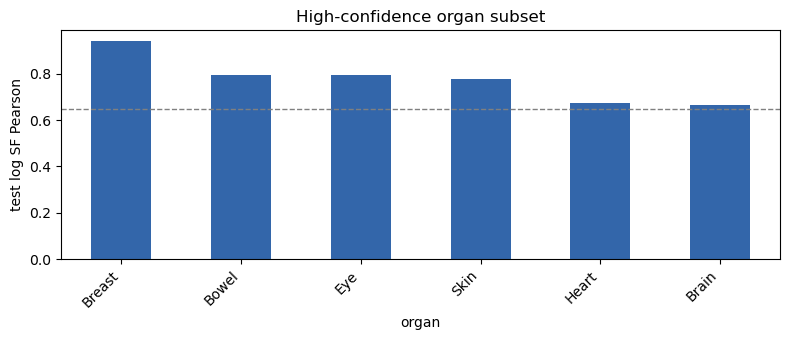

In [3]:
main_dir = runs["full_distribution_light_on_highconf"]
organ_metrics = pd.read_csv(main_dir / "metrics_by_organ_uncalibrated.csv")
organ_metrics = organ_metrics[organ_metrics["split"] == "test"].sort_values("log_sf_pearson", ascending=False)
display(organ_metrics[[
    "organ",
    "log_sf_pearson",
    "sf_pearson",
    "log_sf_mae",
    "sf_std_ratio",
    "sf_top_decile_mean_ratio",
    "n_spots",
]].round(4))

ax = organ_metrics.set_index("organ")["log_sf_pearson"].plot(kind="bar", figsize=(8, 3.5), color="#3366AA")
ax.axhline(0.65, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("test log SF Pearson")
ax.set_xlabel("organ")
ax.set_title("High-confidence organ subset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. 空间图例

下面展示主模型的两个代表性 test slides。每张图从左到右是 true log SF、pred log SF、calibrated pred log SF、residual。

### TENX91

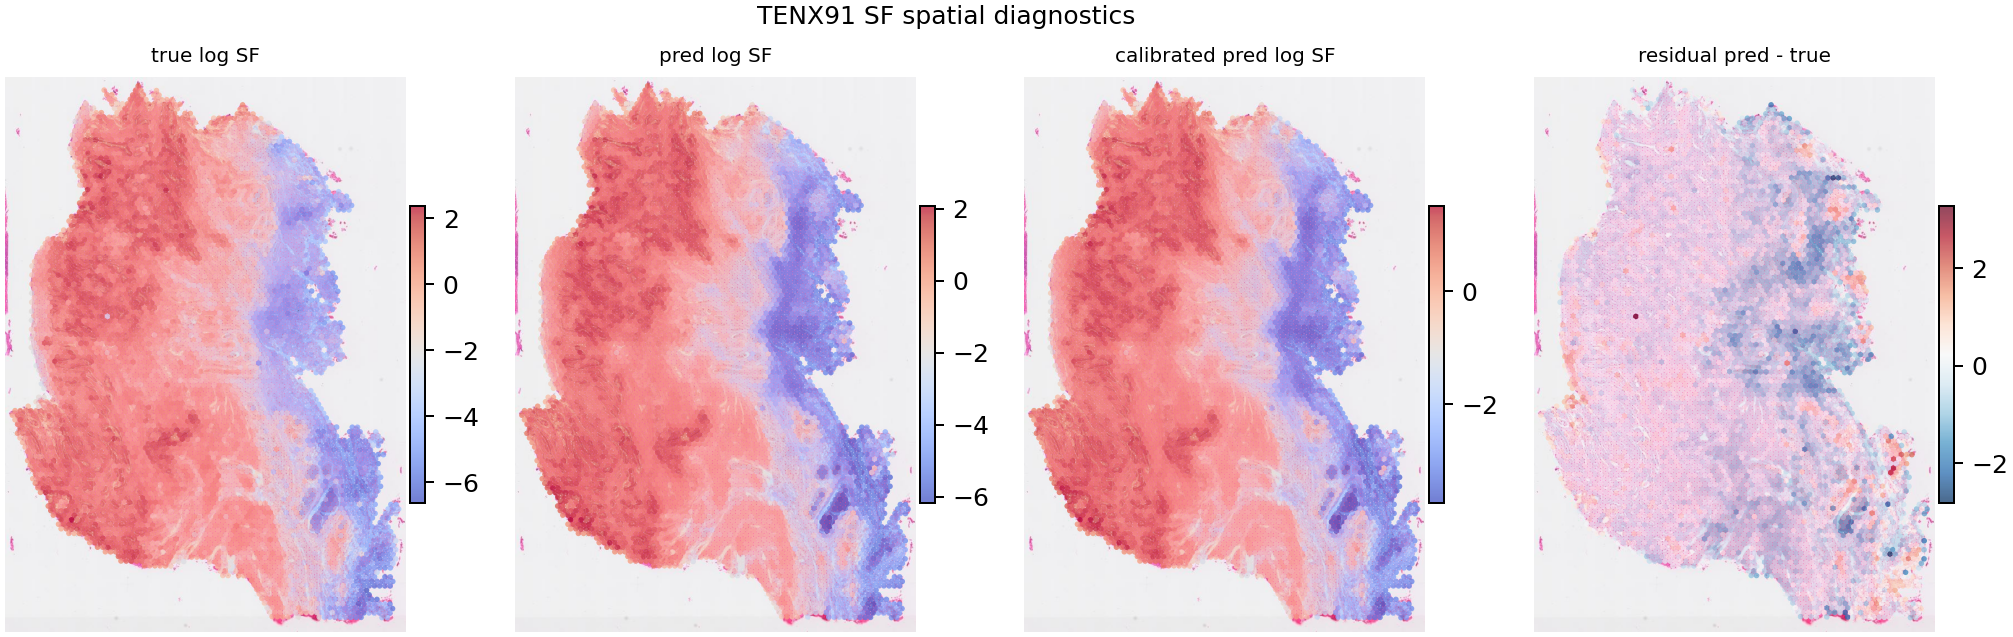

### TENX23

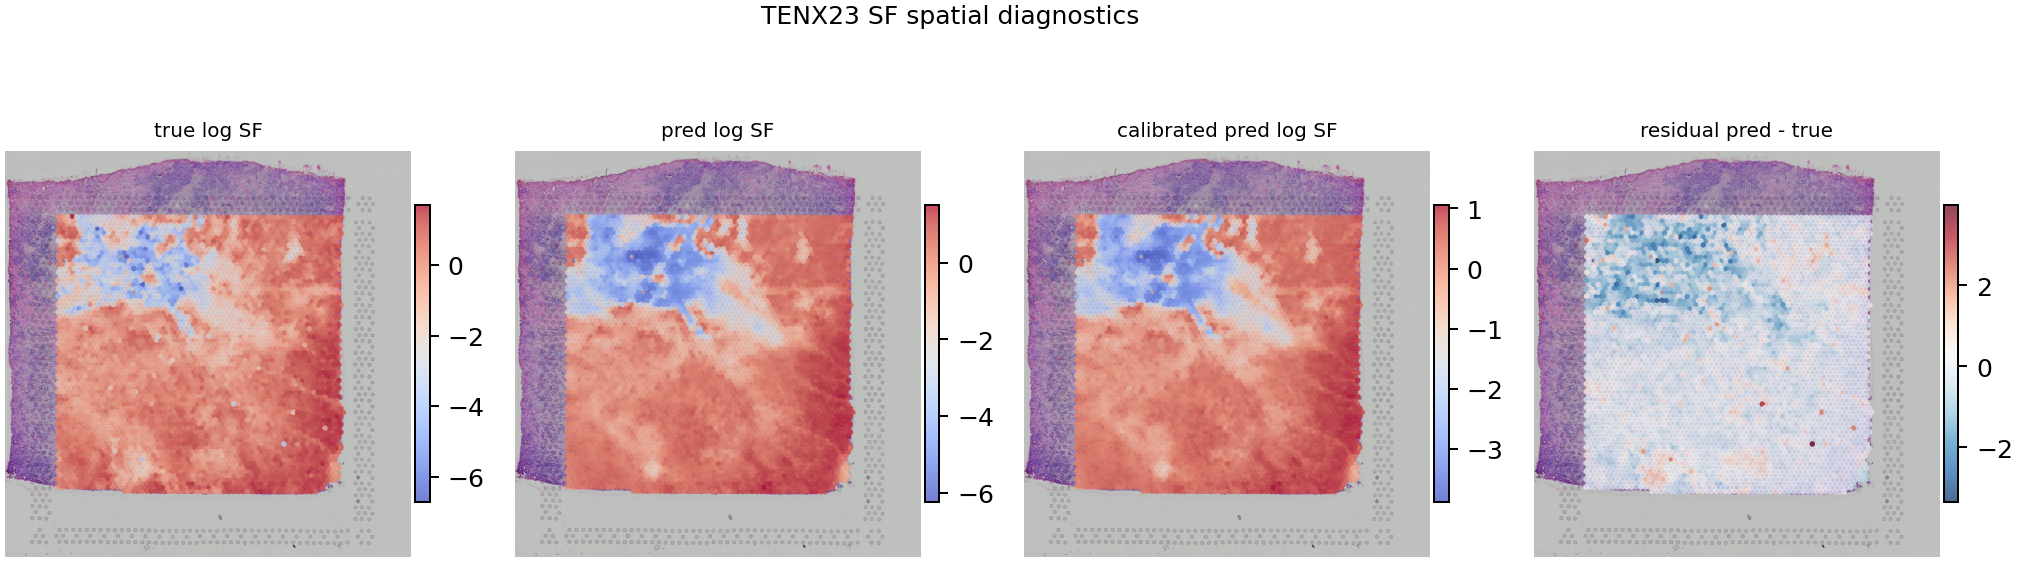

In [4]:
for slide_id in ["TENX91", "TENX23"]:
    image_path = main_dir / "plots" / "spatial" / f"{slide_id}_sf_spatial_diagnostics.png"
    display(Markdown(f"### {slide_id}"))
    display(Image(filename=str(image_path)))

## 4. 当前主线决定

1. 主结论只报告 high-confidence organ subset：Breast、Bowel、Eye、Skin、Heart、Brain。
2. SF 主模型使用全量 human Visium 训练得到的 `context + light distribution` checkpoint。
3. 低表现 organ 不用于主结论，但保留为 failure-mode/stress-test 记录。
4. 下一步进入 HE-to-ST count-scale 预测，比较 direct count、rate-only、rate + SF 三条路线。